# Student Performance Analysis using Machine Learning

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Data Generation

In [4]:
np.random.seed(42)

data = pd.DataFrame({
    "hours_studied": np.random.randint(1, 10, 100),
    "attendance": np.random.randint(50, 100, 100),
    "sleep_hours": np.random.randint(4, 10, 100),
})

data["final_score"] = (
    data["hours_studied"] * 5 +
    data["attendance"] * 0.3 +
    data["sleep_hours"] * 2 +
    np.random.randint(-5, 5, 100)
)


## Data Analysis & Statistics

In [5]:
data.head()

,hours_studied,attendance,sleep_hours,final_score
0,7,84,9,80.2
1,4,86,8,57.8
2,8,96,7,81.8
3,5,63,5,48.9
4,7,52,9,63.6


In [6]:
data.describe()

,hours_studied,attendance,sleep_hours,final_score
count,100.000000,100.0000,100.000000,100.000000
mean,5.320000,74.5200,6.440000,61.216000
std,2.639559,14.8545,1.759936,14.145869
min,1.000000,50.0000,4.000000,33.000000
25%,3.000000,62.0000,5.000000,48.975000
50%,5.000000,77.0000,6.000000,62.500000
75%,8.000000,86.5000,8.000000,72.725000
max,9.000000,98.0000,9.000000,88.400000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hours_studied  100 non-null    int64  
 1   attendance     100 non-null    int64  
 2   sleep_hours    100 non-null    int64  
 3   final_score    100 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


In [8]:
data.corr()

,hours_studied,attendance,sleep_hours,final_score
hours_studied,1.000000,-0.009954,-0.071929,0.908656
attendance,-0.009954,1.000000,-0.290122,0.248080
sleep_hours,-0.071929,-0.290122,1.000000,0.100579
final_score,0.908656,0.248080,0.100579,1.000000


<Axes: >

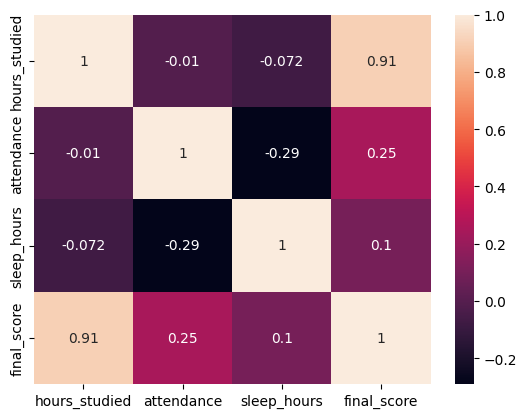

In [9]:
sns.heatmap(data.corr(),annot=True)

<Axes: xlabel='final_score', ylabel='Count'>

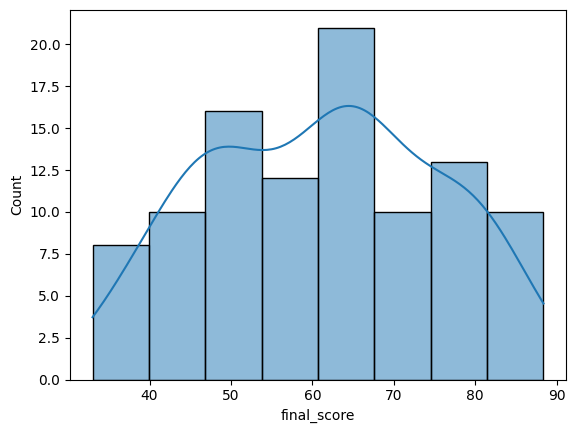

In [10]:
sns.histplot(data["final_score"],kde=True)

## Hypothesis Testing

In [11]:
from scipy.stats import ttest_ind

high_study = data[data["hours_studied"] > 5]["final_score"]
low_study = data[data["hours_studied"] <= 5]["final_score"]

# t-test
t_stat, p_value = ttest_ind(high_study, low_study)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 12.632649987949796
P-value: 2.7645284246817456e-22


## Machine Learning Models

In [12]:
from sklearn.model_selection import train_test_split

X = data[["hours_studied", "attendance", "sleep_hours"]]
y = data["final_score"]

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9577206287579356


In [14]:
data["pass"] = data["final_score"].apply(lambda x: 1 if x >= 50 else 0)
X = data[["hours_studied", "attendance", "sleep_hours"]]
y = data["pass"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9


In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
data["cluster"] = kmeans.fit_predict(data[["hours_studied", "attendance", "sleep_hours"]])

data.head()

,hours_studied,attendance,sleep_hours,final_score,pass,cluster
0,7,84,9,80.2,1,2
1,4,86,8,57.8,1,0
2,8,96,7,81.8,1,0
3,5,63,5,48.9,0,1
4,7,52,9,63.6,1,1


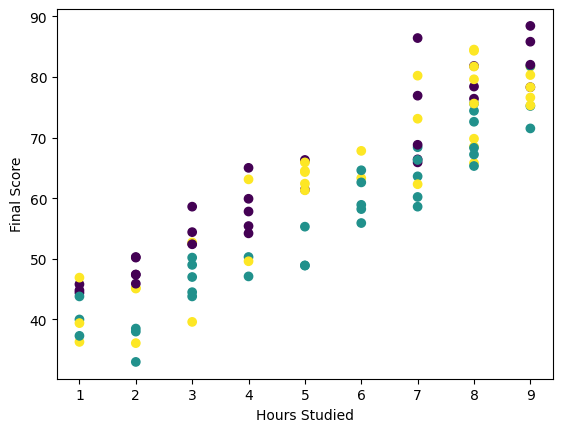

In [17]:
plt.scatter(data["hours_studied"], data["final_score"], c=data["cluster"])
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")
plt.show()

## Conclusion

- Students who study more tend to score significantly higher (validated using hypothesis testing).
- Strong correlation observed between study hours and final score.
- Regression model achieved good R² score, indicating strong predictive performance.
- Classification model successfully predicted pass/fail outcomes with good accuracy.
- Clustering revealed different student performance groups.

This project demonstrates the application of machine learning and statistical techniques to analyze and predict student performance.